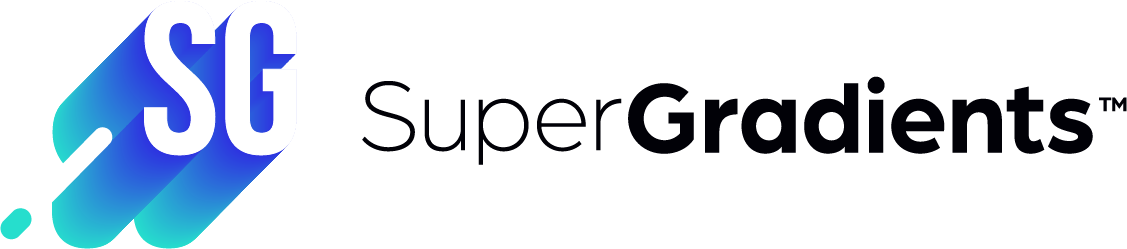

# SuperGradients - Post-Training Quantization and Quantization-Aware Training - Classification

In this tutorial we will train and evaluate ResNet50 transfer learning from Imagenet to CIFAR10 for image classification, then perform PTQ and then QAT on it.


The notebook is divided into 8 sections:
1. Experiment setup
2. Dataset definition
3. Architecture definition
4. Transfer learning: Imagenet -> CIFAR10
5. Post-training quantization and evalutaion
6. Quantization-aware training and evaluation
7. Predict
8. Convert to ONNX

Full tutorial can be found [here](https://github.com/Deci-AI/super-gradients/blob/master/documentation/source/ptq_qat.md)

SuperGradient's Recipes for PTQ/QAT can be found [here](https://github.com/Deci-AI/super-gradients/tree/master/src/super_gradients/recipes/quantization_params)

**Note: quantization is currently supported exclusively for GPU and TensorRT environments.**

#Install SG and deci's dependecies


In [1]:
!pip -qq install super-gradients==3.8.0 pytorch-quantization==2.1.2 --extra-index-url https://pypi.ngc.nvidia.com

# 1. Experiment setup

We will first initialize our **trainer** which will be in charge of everything, like training, evaluation, saving checkpoints, plotting etc.

The **experiment name** argument is important as every checkpoints, logs and tensorboards to be saved in a directory with the same name. This directory will be created as a sub-directory of **ckpt_root_dir** as follow:

```
ckpt_root_dir
|─── experiment_name_1
│       ckpt_best.pth                     # Model checkpoint on best epoch
│       ckpt_latest.pth                   # Model checkpoint on last epoch
│       average_model.pth                 # Model checkpoint averaged over epochs
│       events.out.tfevents.1659878383... # Tensorflow artifacts of a specific run
│       log_Aug07_11_52_48.txt            # Trainer logs of a specific run
└─── experiment_name_2
        ...
```

In this notebook multi-gpu training is set as `OFF`, for Distributed training multi_gpu can be set as
 `MultiGPUMode.DISTRIBUTED_DATA_PARALLEL` or `MultiGPUMode.DATA_PARALLEL`.

 Note that QAT does not support `MultiGPUMode.DISTRIBUTED_DATA_PARALLEL`, so keep it off for your QAT runs.


In [2]:
from super_gradients import Trainer
import pprint

experiment_name = "cifar10_ptq_qat_classification"

CHECKPOINT_DIR = 'checkpoints'
trainer = Trainer(experiment_name=experiment_name, ckpt_root_dir=CHECKPOINT_DIR)

# 2. Dataset definition


For the sake of this presentation, We'll use CIFAR10 data set that can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

You can see the internal structure and file definition there, too.

We will use `torchvision` dataset implementation from [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).

SuperGradients wil handle its download for you.



There is a pool of standard datasets and dataloaders in Super Gradients. It will gracefully handle their creation for you. Now, let's import the dataloaders. Also, they are coming with recipes that include transforms, batch size and everything, so default loading is just as easy as two lines of code.

In [3]:
from super_gradients.training import dataloaders

train_dataloader = dataloaders.get("cifar10_train", dataset_params={}, dataloader_params={"num_workers": 2, "persistent_workers": True})
valid_dataloader = dataloaders.get("cifar10_val", dataset_params={}, dataloader_params={"num_workers": 2, "persistent_workers": True})

Let's visualize what we've got there.

We have images and labels, with the default batch size of 256 for training.

In [4]:
from matplotlib import pyplot as plt

def show(images, labels, classes, rows=6, columns=5):
  fig = plt.figure(figsize=(10, 10))

  for i in range(1, columns * rows + 1):
      fig.add_subplot(rows, columns, i)
      plt.imshow(images[i-1].permute(1, 2, 0).clamp(0, 1))
      plt.xticks([])
      plt.yticks([])
      plt.title(f"{classes[labels[i-1]]}")

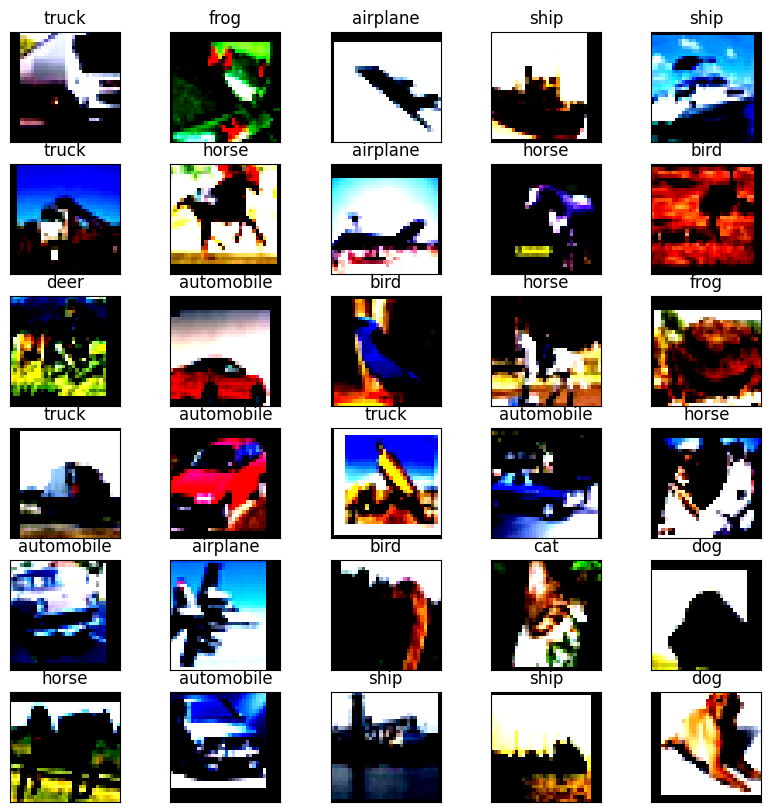

In [5]:
vis_images_train, vis_labels_train = next(iter(train_dataloader))
show(vis_images_train, vis_labels_train, classes=train_dataloader.dataset.classes)

print(vis_images_train.shape, vis_labels_train.shape)


# 3. Architecture definition

SG includes implementations of many different architectures for classification tasks.

The architecture that uses here is [ResNet50](https://arxiv.org/abs/1512.03385). We are going to use weights pretrained on the Imagenet dataset as a starting point.

In [6]:
from super_gradients.training import models
from super_gradients.common.object_names import Models

model = models.get(model_name=Models.RESNET50, num_classes=10, pretrained_weights="imagenet")

# 4. Transfer learning: Imagenet -> CIFAR10


The training parameters for this use case were optimized per dataset and architecture and the type of training (from scratch\transfer learning).
For more recommended training params you can have a look at our recipes [here](https://github.com/Deci-AI/super-gradients/tree/master/src/super_gradients/recipes).

In [7]:
from super_gradients.training import Trainer
from super_gradients.training import training_hyperparams

# you can see more recipes in super_gradients/recipes
training_params =  training_hyperparams.get("training_hyperparams/cifar10_resnet_train_params")


There are a many hidden things going on. We will have to modify some of them for QAT. Let's disclose them:

In [8]:
pprint.pprint("Training parameters")
pprint.pprint(training_params)

We need to override some parameters for the sake of this presentation:

In [9]:
training_params["initial_lr"] = 0.1
training_params["max_epochs"] = 15
training_params["lr_updates"] = [10, 25, 45]
training_params["lr_warmup_epochs"] = 5
training_params["warmup_initial_lr"] = 0.01

We connect the tensor board to our CKPT path to see updates live.

In [10]:
%load_ext tensorboard
%tensorboard --logdir checkpoints

Launching TensorBoard...

In [11]:
trainer.train(model=model,
              training_params=training_params,
              train_loader=train_dataloader,
              valid_loader=valid_dataloader)

Validating epoch 15:  85%|████████▌ | 17/20 [00:03<00:00,  5.44it/s]

Let's load the best checkpoint to the model and validate it:

In [12]:
import copy
import os
import sys
import torch
from torch import nn
from super_gradients.training.utils.quantization.calibrator import QuantizationCalibrator
from super_gradients.training.utils.quantization.export import export_quantized_module_to_onnx
from super_gradients.training.utils.quantization.selective_quantization_utils import SelectiveQuantizer
from super_gradients.modules.repvgg_block import fuse_repvgg_blocks_residual_branches

def load_checkpoint(model, ckpt_file):
  checkpoint = torch.load(ckpt_file, map_location="cpu")
  ckpt_key = "ema_net" if "ema_net" in checkpoint else "net"
  state_dict = checkpoint[ckpt_key]
  model.load_state_dict(state_dict)

def validate_model(model, dataloader, training_hyperparams):
  trainer = Trainer(experiment_name=experiment_name, ckpt_root_dir=CHECKPOINT_DIR)

  valid_metrics_dict = trainer.test(model=model, test_loader=dataloader, test_metrics_list=training_hyperparams.get("valid_metrics_list"))

  results = ["Validate Results"]
  results += [f"\t- {metric:4}: {value:.3f}" for metric, value in valid_metrics_dict.items()]

  res_string = "\r\n".join(results)

  print(res_string, file=sys.stderr)

  return valid_metrics_dict


load_checkpoint(model, os.path.join(trainer.checkpoints_dir_path, "ckpt_best.pth"))
validate_model(model, valid_dataloader, training_params)

Testing:  85%|████████▌ | 17/20 [00:03<00:00,  5.42it/s]

{'Accuracy': 0.8783000111579895, 'Top5': 0.9955000281333923}

# 6. Post-Training Quantization (PTQ) on the trained model


Quantization-Aware Training is performed on the already quantized model. 
So we have to perform Post-Training Quantization to create a starting checkpoint, or use it as-is later.

To perform PTQ, we have to insert properly initialized quantization and dequantization layers into our network. 
SuperGradients will handle it for you for all of the basic layerss but will have to do it yourself, if there is something custom in the network.

`SelectiveQuantizer` handles the insertion of Q/DQ blocks, while `QuantizationCalibrator` performs their initialization.


Quantization routine is pretty straightforward: we first quantize the model and then calibrate it.

Note: quantization is performed in-place!

In [13]:
def quantize_and_calibrate(
    model: nn.Module,
    calibration_dataloader,
    num_calib_batches=16,             # number of batches to use for calibration
    method_w="max",                   # calibrator type for weights, acceptable types are ["max", "histogram"]
    method_i="histogram",             # calibrator type for inputs, acceptable types are ["max", "histogram"]
    calibration_method="percentile",  # calibration method for all "histogram" calibrators, acceptable types are ["percentile", "entropy", mse"], "max" calibrators are not affected
    percentile=99.99,                 # percentile for all histogram calibrators with method "percentile", other calibrators are not affected
    per_channel=True,                 # per-channel quantization of weights, activations stay per-tensor by default
    learn_amax=False,                 # enable learnable amax in all TensorQuantizers using straight-through estimator
    skip_modules=None,                # optional list of module names (strings) to skip from quantization
    verbose=False,                    # if calibrator should be verbose
):
    model.eval()

    q_util = SelectiveQuantizer(
        default_quant_modules_calibrator_weights=method_w,
        default_quant_modules_calibrator_inputs=method_i,
        default_per_channel_quant_weights=per_channel,
        default_learn_amax=learn_amax,
        verbose=verbose
    )

    if skip_modules is not None:
        q_util.register_skip_quantization(layer_names=set(skip_modules))

    calibrator = QuantizationCalibrator(verbose=verbose, torch_hist=True)

    # RepVGG and QARepVGG can be quantized only in the fused form
    fuse_repvgg_blocks_residual_branches(model)
    q_util.quantize_module(model)

    calibrator.calibrate_model(
        model,
        method=calibration_method,
        calib_data_loader=calibration_dataloader,
        num_calib_batches=num_calib_batches,
        percentile=percentile,
    )

    model.train()
    return model


First, load the best checkpoint to the model, then perform quantization:

You can play with quantization parameters here and see how it affects `ptq_model`'s accuracy.

In [14]:
load_checkpoint(model, os.path.join(trainer.checkpoints_dir_path, "ckpt_best.pth"))
ptq_model = quantize_and_calibrate(copy.deepcopy(model),
                                    train_dataloader,
                                    num_calib_batches=4,
                                    method_w="max",
                                    method_i="histogram",
                                    calibration_method="percentile",
                                    percentile=99.99,
                                    per_channel=True,
                                    learn_amax=False,
                                    skip_modules=None,
                                    verbose=False)

Testing: 100%|██████████| 20/20 [00:03<00:00,  5.28it/s]
Validate Results
	- Accuracy: 0.878
	- Top5: 0.996
100%|██████████| 4/4 [00:00<00:00,  5.00it/s]

In [15]:
validate_model(ptq_model, valid_dataloader, training_params)

Testing:  90%|█████████ | 18/20 [00:03<00:00,  5.81it/s]

{'Accuracy': 0.8751000165939331, 'Top5': 0.9950000047683716}

# 7. Quantization-Aware training

In essence, quantization-aware training is training of the model after PTQ. It can be looked as finetuning of the model with newly-accustomed Q/DQ layers.

So, we have to treat it like finetuning: smaller learning rate and weight decay, different learning rate schedule:

In [16]:
training_params["max_epochs"] = 10
training_params["initial_lr"] = 1e-4
training_params["warmup_initial_lr"] = 1e-6
training_params["weight_decay"] = 1e-5
training_params["lr_mode"] = "cosine"
training_params["lr_warmup_epochs"] = 1
training_params["cosine_final_lr_ratio"] = 0.01
training_params["ema"] = False

train_dataloader.dataset.transforms = copy.deepcopy(valid_dataloader.dataset.transforms)

Dont't forget to check out Tensorboard up there!

In [17]:
trainer_qat = Trainer(experiment_name=f"{experiment_name}_qat", ckpt_root_dir=CHECKPOINT_DIR)
trainer_qat.train(model=ptq_model,
              training_params=training_params,
              train_loader=train_dataloader,
              valid_loader=valid_dataloader)

Testing: 100%|██████████| 20/20 [00:04<00:00,  4.94it/s]
Validate Results
	- Accuracy: 0.875
	- Top5: 0.995
Validating epoch 10: 100%|██████████| 20/20 [00:04<00:00,  4.62it/s]


In [18]:
load_checkpoint(ptq_model, os.path.join(trainer_qat.checkpoints_dir_path, "ckpt_best.pth"))
validate_model(ptq_model, valid_dataloader, training_params)

Testing:  85%|████████▌ | 17/20 [00:04<00:00,  4.02it/s]

{'Accuracy': 0.8776999711990356, 'Top5': 0.995199978351593}

# Predicting with the model

As the training was complete you can use the trained model to predict on your data

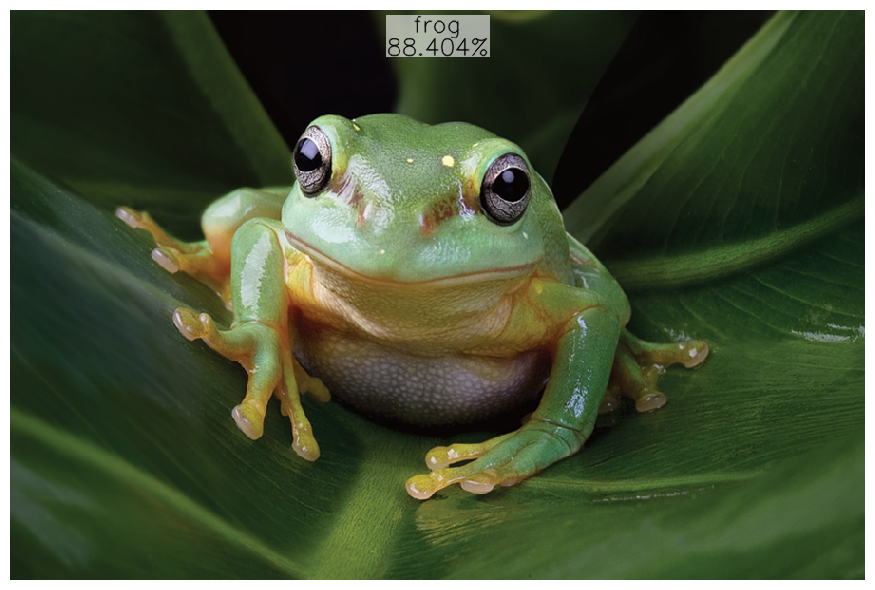

In [21]:
ptq_model.predict("https://www.aquariumofpacific.org/images/exhibits/Magnificent_Tree_Frog_900.jpg").show()

# 7. Convert to ONNX


SG is a Production ready library. All the models implemented in SG can be compiled to ONNX, even quantized ones. You can download ONNX file from the files tab.

In [24]:
import torch
onnx_filename = f"qat_model_cifar10_1x3x32x32.onnx"

export_quantized_module_to_onnx(
    model=ptq_model.cpu(),
    onnx_filename=onnx_filename,
    input_shape=(1, 3, 32, 32),
    train=False,
)

## 8. Wrapping up

In [25]:
trainer.qat(
    model=model,
    train_loader=train_dataloader,
    valid_loader=valid_dataloader,
    calib_loader=valid_dataloader,
    training_params=training_params,
)

Validating epoch 10: 100%|██████████| 20/20 [00:03<00:00,  5.05it/s]


## Additional resources

* [Post-Training Quantization (PTQ) and Quantization-Aware Training (QAT)](https://docs.deci.ai/super-gradients/latest/documentation/source/ptq_qat.html)